# Visualização da grade federada (FedAvg) — DAGHAR / HAR

Análise dos resultados da **grade federada completa** rodada no cluster:
**96 runs = 8 cenários × 3 encoders × 4 seeds**, `R = 50` rodadas de FedAvg,
avaliação **centralizada por domínio** nos 6 test sets do DAGHAR.

Fonte: `results/federated_eval.csv`
(`encoder, scenario, seed, round, target, test_acc, test_f1_macro, uplink_bytes, downlink_bytes`).

**Cenários de particionamento**

| Cenário | Partição | Tipo FL |
|---|---|---|
| **1** | 1 dataset DAGHAR por cliente (6 clientes = 6 domínios) | **non-IID por domínio** (oficial) |
| **2** | união dos 6 train sets em 6 fatias IID disjuntas | **IID global** (controle) |
| **3..8** | 1 dataset dividido IID nos 6 clientes (um por cenário) | IID intra-domínio (ablação) |

A comparação **1 vs 2** (mesmo volume total de dados) isola o efeito do *domain
shift*. Os cenários **3..8** formam, juntos, uma **matriz de transfer federada
6×6** (treino federado em 1 domínio → avaliação nos 6).

**Métricas do plano oficial:** acurácia, F1-macro e **custo de comunicação**
(uplink / downlink / total por rodada).

Estrutura do notebook:
1. Setup e carga dos dados
2. Cobertura / sanidade da grade
3. **Análises individuais** — curvas de convergência FedAvg por experimento
4. **Resultados agregados** — por modelo e por dataset (rodada final)
5. **Análise de domain shift** — non-IID vs IID, vs baseline centralizado, matriz de transfer federada
6. **Custo de comunicação** — uplink/downlink/total e eficiência acurácia × comunicação

## 1. Setup e carga dos dados

In [1]:
import sys
import warnings
from pathlib import Path

# Localiza a raiz do projeto subindo a árvore (mesmo padrão do notebook centralizado).
_p = Path.cwd()
PROJECT_ROOT = None
while _p != _p.parent:
    if (_p / "minerva").is_dir() and (_p / "scripts").is_dir():
        PROJECT_ROOT = _p
        break
    _p = _p.parent
if PROJECT_ROOT is None:
    raise RuntimeError(f"Raiz do projeto não encontrada a partir de {Path.cwd()}")
for p in (PROJECT_ROOT, PROJECT_ROOT / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /home/miguel/fed-har


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
    HAS_SNS = True
except Exception:  # seaborn é opcional; heatmaps caem para matplotlib puro
    HAS_SNS = False

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 140)
print("seaborn disponível:", HAS_SNS)

seaborn disponível: True


In [3]:
# Ordem canônica dos datasets DAGHAR (importada do código para casar com os cenários 3..8).
from common import DATASETS  # ['UCI', 'MotionSense', 'KuHar', 'WISDM', 'RealWorld_thigh', 'RealWorld_waist']

ENCODERS = ["resnetse5", "cnnpff", "rnn"]
ENCODER_LABEL = {"resnetse5": "ResNet-SE-5", "cnnpff": "CNN-PFF", "rnn": "BiGRU"}

# Cenário 3+i -> DATASETS[i] (mesma regra de scripts/federated/partitions.py).
SCENARIO_TO_DATASET = {3 + i: name for i, name in enumerate(DATASETS)}

def scenario_label(s: int) -> str:
    """Rótulo legível de um cenário."""
    if s == 1:
        return "non-IID (1 domínio/cliente)"
    if s == 2:
        return "IID global"
    return f"IID intra-domínio · {SCENARIO_TO_DATASET[s]}"

def scenario_short(s: int) -> str:
    if s == 1:
        return "non-IID"
    if s == 2:
        return "IID global"
    return SCENARIO_TO_DATASET[s]

# Paleta consistente (colorblind-friendly), alinhada ao notebook centralizado.
C_NONIID   = "#DE8F05"  # laranja — heterogêneo (domain shift presente)
C_IID      = "#0173B2"  # azul    — homogêneo (controle)
C_CENTRAL  = "#029E73"  # verde   — referência centralizada (combined)
HEATMAP_CMAP = "mako" if HAS_SNS else "viridis"
ENCODER_COLORS = {"resnetse5": "#0173B2", "cnnpff": "#DE8F05", "rnn": "#029E73"}

print("Encoders:", ENCODERS)
print("Cenários 3..8 ->", SCENARIO_TO_DATASET)

Encoders: ['resnetse5', 'cnnpff', 'rnn']
Cenários 3..8 -> {3: 'UCI', 4: 'MotionSense', 5: 'KuHar', 6: 'WISDM', 7: 'RealWorld_thigh', 8: 'RealWorld_waist'}


In [4]:
# ── Carga dos resultados federados ──────────────────────────────────────────
FED_CSV = PROJECT_ROOT / "results" / "federated_eval.csv"
df = pd.read_csv(FED_CSV)
df["round"] = df["round"].astype(int)
df["scenario"] = df["scenario"].astype(int)
df["seed"] = df["seed"].astype(int)
df["total_bytes"] = df["uplink_bytes"] + df["downlink_bytes"]

# Referência centralizada: modelo generalista `combined` (treino na união dos 6).
SUP_CSV = PROJECT_ROOT / "results" / "supervised_eval_transfer.csv"
sup = pd.read_csv(SUP_CSV) if SUP_CSV.exists() else None
if sup is not None:
    central_combined = (
        sup[sup["source"] == "combined"]
        .groupby("target")[["test_acc", "test_f1_macro"]]
        .mean()
    )
else:
    central_combined = None

print(f"federated_eval.csv: {df.shape[0]} linhas")
print(df.head(3).to_string(index=False))

federated_eval.csv: 29376 linhas
encoder  scenario  seed  round          target  test_acc  test_f1_macro  uplink_bytes  downlink_bytes  total_bytes
 cnnpff         1     0      0           KuHar  0.156250       0.126112             0               0            0
 cnnpff         1     0      0     MotionSense  0.152344       0.095932             0               0            0
 cnnpff         1     0      0 RealWorld_thigh  0.135764       0.079032             0               0            0


## 2. Cobertura e sanidade da grade

Confere que os **96 runs** (8 cenários × 3 encoders × 4 seeds) chegaram à rodada
final (`round == 50`), com os 6 domínios avaliados em cada rodada.

In [5]:
LAST_ROUND = int(df["round"].max())
combos = df.groupby(["encoder", "scenario", "seed"]).ngroups
done = df[df["round"] == LAST_ROUND].groupby(["encoder", "scenario", "seed"]).ngroups
print(f"Rodada final: R = {LAST_ROUND}")
print(f"Combinações (encoder×cenário×seed): {combos} / 96")
print(f"Combinações com round=={LAST_ROUND}: {done} / 96")
print(f"Domínios-alvo avaliados: {sorted(df['target'].unique())}")
print(f"Seeds: {sorted(df['seed'].unique())}  |  Rodadas distintas: {df['round'].nunique()} (0..{LAST_ROUND})")

# Linhas por combinação = 51 rodadas × 6 domínios = 306 (sanidade)
per_combo = df.groupby(["encoder", "scenario", "seed"]).size()
print(f"\nLinhas por combinação — min/mediana/max: "
      f"{per_combo.min()} / {int(per_combo.median())} / {per_combo.max()} (esperado 306)")

Rodada final: R = 50
Combinações (encoder×cenário×seed): 96 / 96
Combinações com round==50: 96 / 96
Domínios-alvo avaliados: ['KuHar', 'MotionSense', 'RealWorld_thigh', 'RealWorld_waist', 'UCI', 'WISDM']
Seeds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  |  Rodadas distintas: 51 (0..50)

Linhas por combinação — min/mediana/max: 306 / 306 / 306 (esperado 306)


In [6]:
# ── Helpers de agregação (média ± std sobre as 4 seeds) ─────────────────────
def agg_over_seeds(frame: pd.DataFrame, by: list[str], metric: str) -> pd.DataFrame:
    """Média e desvio-padrão de `metric` sobre seeds, agrupando por `by`."""
    g = frame.groupby(by)[metric]
    return g.agg(mean="mean", std="std").reset_index()

def final_round(frame: pd.DataFrame | None = None) -> pd.DataFrame:
    """Subconjunto da rodada final (modelo federado convergido)."""
    f = df if frame is None else frame
    return f[f["round"] == LAST_ROUND]

def fmt_pct(mean, std=None) -> str:
    if std is None or np.isnan(std):
        return f"{100*mean:.1f}"
    return f"{100*mean:.1f} ± {100*std:.1f}"

FINAL = final_round()
print("Rodada final isolada:", FINAL.shape[0], "linhas")

Rodada final isolada: 576 linhas


## 3. Análises individuais dos experimentos — convergência FedAvg

Cada *experimento* é uma combinação **(encoder, cenário)**; as curvas mostram a
média ± desvio-padrão sobre as 4 seeds da acurácia/F1-macro **centralizada por
domínio** ao longo das 50 rodadas de FedAvg. Os cenários **1 (non-IID)** e
**2 (IID global)** são os mais informativos do plano oficial.

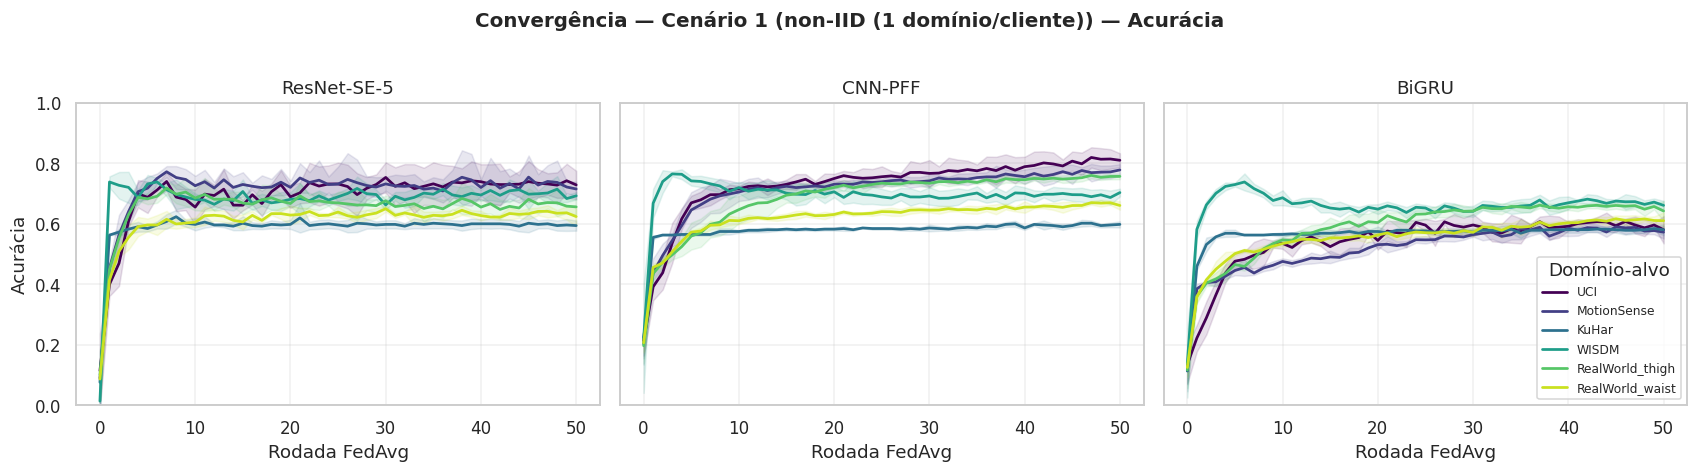

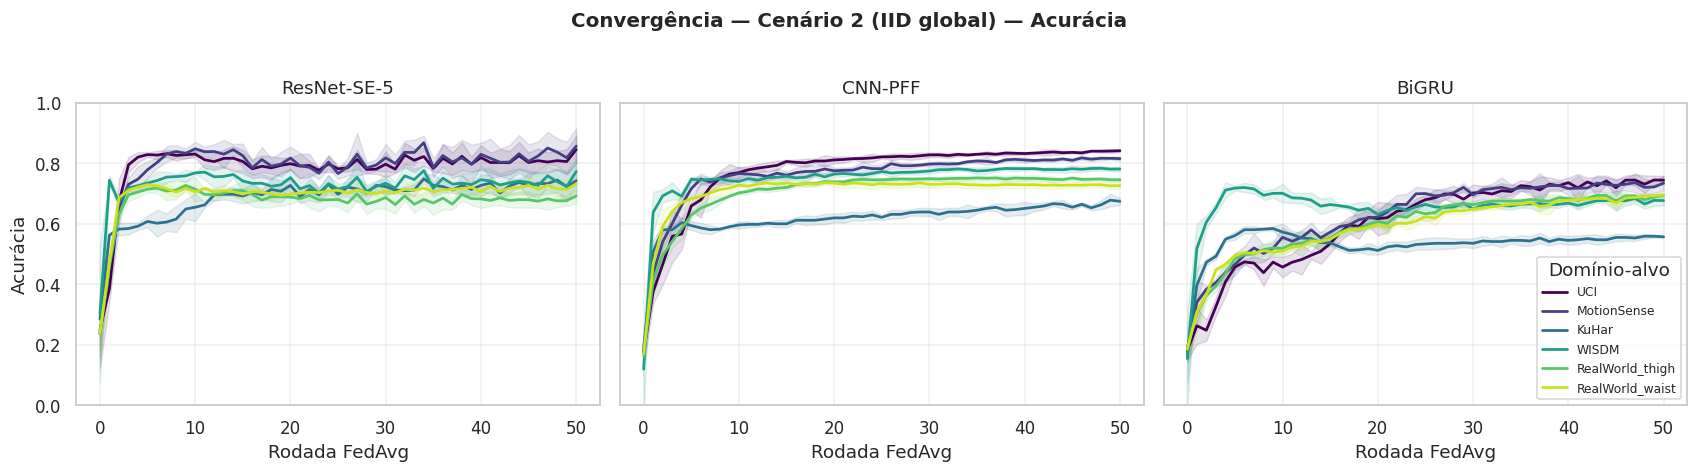

In [7]:
def plot_convergence(scenario: int, metric: str = "test_acc"):
    """Curvas de convergência por encoder (colunas) e domínio-alvo (linhas)."""
    sub = df[df["scenario"] == scenario]
    fig, axes = plt.subplots(1, len(ENCODERS), figsize=(5.2 * len(ENCODERS), 4.2), sharey=True)
    metric_lbl = "Acurácia" if metric == "test_acc" else "F1-macro"
    cmap = plt.cm.viridis(np.linspace(0, 0.92, len(DATASETS)))
    for ax, enc in zip(axes, ENCODERS):
        e = sub[sub["encoder"] == enc]
        for color, tgt in zip(cmap, DATASETS):
            curve = agg_over_seeds(e[e["target"] == tgt], ["round"], metric).sort_values("round")
            ax.plot(curve["round"], curve["mean"], color=color, label=tgt, lw=1.8)
            ax.fill_between(curve["round"], curve["mean"] - curve["std"],
                            curve["mean"] + curve["std"], color=color, alpha=0.12)
        ax.set_title(ENCODER_LABEL[enc])
        ax.set_xlabel("Rodada FedAvg")
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(metric_lbl)
    axes[-1].legend(title="Domínio-alvo", fontsize=8, loc="lower right")
    fig.suptitle(f"Convergência — Cenário {scenario} ({scenario_label(scenario)}) — {metric_lbl}",
                 y=1.02, fontsize=13, weight="bold")
    fig.tight_layout()
    plt.show()

plot_convergence(1, "test_acc")
plot_convergence(2, "test_acc")

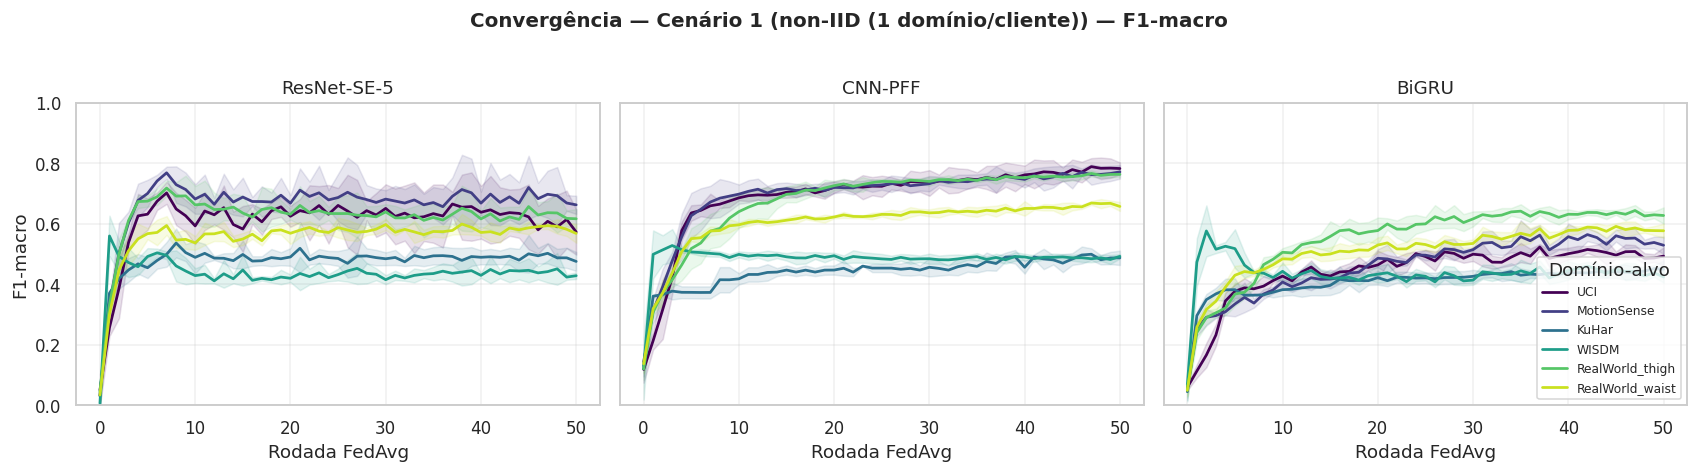

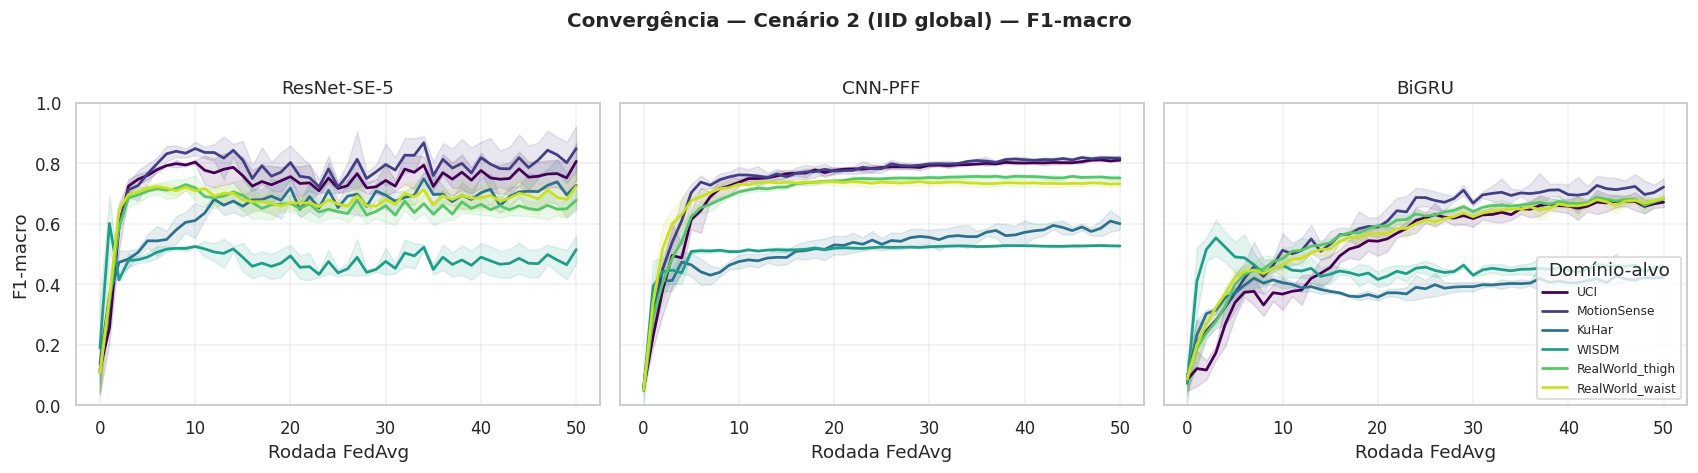

In [8]:
# F1-macro (mesma estrutura) para os dois cenários principais.
plot_convergence(1, "test_f1_macro")
plot_convergence(2, "test_f1_macro")

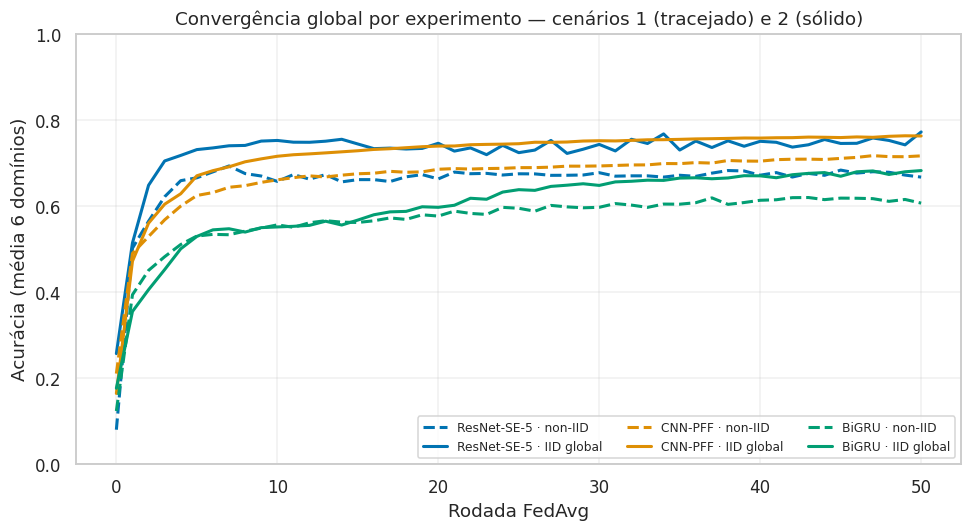

In [9]:
# Curva agregada (média sobre os 6 domínios) — visão de "uma linha por experimento".
def plot_global_convergence(metric: str = "test_acc"):
    fig, ax = plt.subplots(figsize=(9, 5))
    metric_lbl = "Acurácia" if metric == "test_acc" else "F1-macro"
    for enc in ENCODERS:
        for scen, ls in [(1, "--"), (2, "-")]:
            e = df[(df["encoder"] == enc) & (df["scenario"] == scen)]
            curve = agg_over_seeds(e, ["round"], metric).sort_values("round")
            ax.plot(curve["round"], curve["mean"], ls, color=ENCODER_COLORS[enc], lw=2,
                    label=f"{ENCODER_LABEL[enc]} · {scenario_short(scen)}")
    ax.set_xlabel("Rodada FedAvg"); ax.set_ylabel(f"{metric_lbl} (média 6 domínios)")
    ax.set_ylim(0, 1); ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=3, loc="lower right")
    ax.set_title(f"Convergência global por experimento — cenários 1 (tracejado) e 2 (sólido)")
    fig.tight_layout(); plt.show()

plot_global_convergence("test_acc")

In [10]:
# Tabela-resumo por experimento (encoder × cenário) na rodada final.
rows = []
for enc in ENCODERS:
    for scen in sorted(df["scenario"].unique()):
        f = FINAL[(FINAL["encoder"] == enc) & (FINAL["scenario"] == scen)]
        if f.empty:
            continue
        # média por seed (sobre domínios) e depois média/std sobre seeds
        per_seed = f.groupby("seed")[["test_acc", "test_f1_macro"]].mean()
        rows.append({
            "encoder": ENCODER_LABEL[enc],
            "cenário": scen,
            "tipo": scenario_short(scen),
            "acc (%)": fmt_pct(per_seed["test_acc"].mean(), per_seed["test_acc"].std()),
            "F1-macro (%)": fmt_pct(per_seed["test_f1_macro"].mean(), per_seed["test_f1_macro"].std()),
        })
summary_exp = pd.DataFrame(rows)
print("Resumo por experimento (rodada final, média±std sobre seeds):")
summary_exp

Resumo por experimento (rodada final, média±std sobre seeds):


,encoder,cenário,tipo,acc (%),F1-macro (%)
0,ResNet-SE-5,1,non-IID,66.8 ± 1.4,55.4 ± 2.2
1,ResNet-SE-5,2,IID global,77.3 ± 3.4,71.6 ± 5.2
2,ResNet-SE-5,3,UCI,49.2 ± 1.1,39.9 ± 1.8
3,ResNet-SE-5,4,MotionSense,52.3 ± 0.9,46.7 ± 0.6
4,ResNet-SE-5,5,KuHar,51.2 ± 1.2,43.9 ± 1.7
5,ResNet-SE-5,6,WISDM,50.7 ± 0.9,38.1 ± 1.0
6,ResNet-SE-5,7,RealWorld_thigh,50.2 ± 1.0,39.4 ± 0.5
7,ResNet-SE-5,8,RealWorld_waist,57.2 ± 4.0,49.5 ± 3.3
8,CNN-PFF,1,non-IID,71.7 ± 0.6,65.9 ± 0.7
9,CNN-PFF,2,IID global,76.4 ± 0.3,70.6 ± 0.6


## 4. Resultados agregados — por modelo e por dataset

Desempenho na **rodada final** (modelo FedAvg convergido), agregando os 3
encoders e/ou as 4 seeds.

### 4.1 Tabela acurácia × F1-macro por encoder e cenário

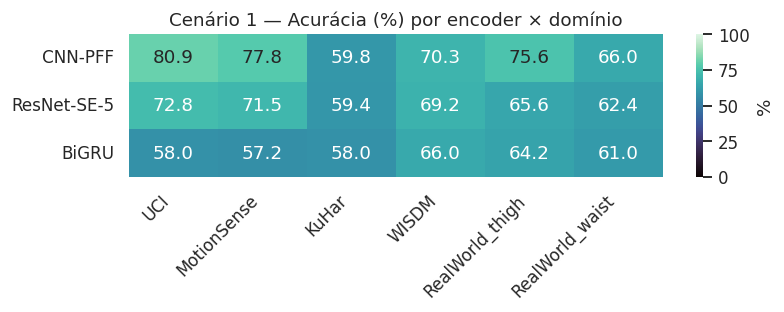

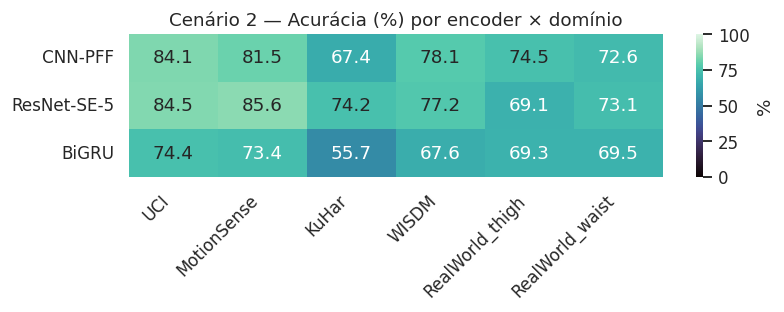

In [11]:
def heat_encoder_target(scenario: int, metric: str = "test_acc"):
    """Heatmap encoder × domínio-alvo na rodada final, para um cenário."""
    f = FINAL[FINAL["scenario"] == scenario]
    piv = (f.groupby(["encoder", "target"])[metric].mean()
             .reindex(pd.MultiIndex.from_product([ENCODERS, DATASETS], names=["encoder", "target"]))
             .unstack("target")[DATASETS])
    piv.index = [ENCODER_LABEL[e] for e in piv.index]
    fig, ax = plt.subplots(figsize=(7.5, 3.0))
    data = piv.values * 100
    if HAS_SNS:
        sns.heatmap(data, annot=True, fmt=".1f", cmap=HEATMAP_CMAP, vmin=0, vmax=100,
                    xticklabels=DATASETS, yticklabels=piv.index, ax=ax,
                    cbar_kws={"label": "%"})
    else:
        im = ax.imshow(data, cmap=HEATMAP_CMAP, vmin=0, vmax=100, aspect="auto")
        ax.set_xticks(range(len(DATASETS))); ax.set_xticklabels(DATASETS, rotation=45, ha="right")
        ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                ax.text(j, i, f"{data[i,j]:.1f}", ha="center", va="center", color="w", fontsize=8)
        fig.colorbar(im, ax=ax, label="%")
    metric_lbl = "Acurácia" if metric == "test_acc" else "F1-macro"
    ax.set_title(f"Cenário {scenario} — {metric_lbl} (%) por encoder × domínio")
    ax.set_xlabel(""); plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    fig.tight_layout(); plt.show()
    return piv

_ = heat_encoder_target(1, "test_acc")
_ = heat_encoder_target(2, "test_acc")

### 4.2 Agregado por dataset (todos os modelos)

Para cada domínio-alvo, agrega os **3 encoders × 4 seeds** e compara o cenário 1
(non-IID) com o cenário 2 (IID global), junto da referência centralizada
`combined`.

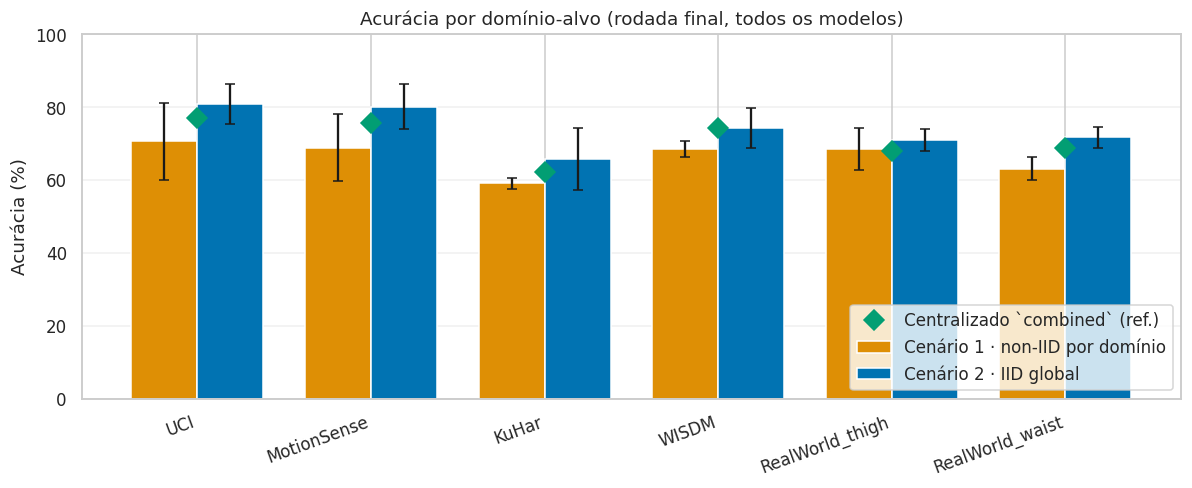

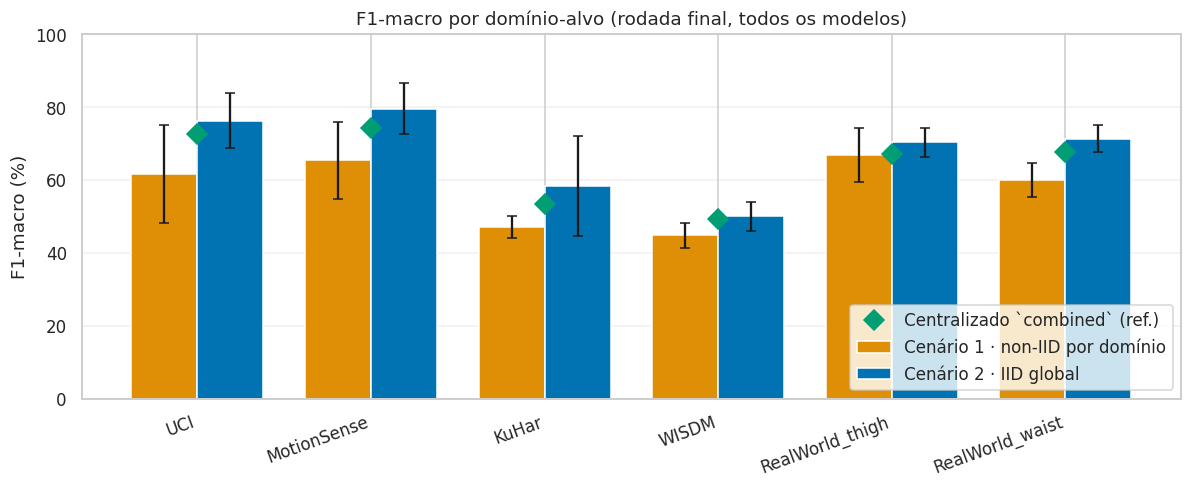

In [12]:
def bar_by_dataset(metric: str = "test_acc"):
    f1 = FINAL[FINAL["scenario"] == 1].groupby("target")[metric].agg(["mean", "std"]).reindex(DATASETS)
    f2 = FINAL[FINAL["scenario"] == 2].groupby("target")[metric].agg(["mean", "std"]).reindex(DATASETS)
    x = np.arange(len(DATASETS)); w = 0.38
    fig, ax = plt.subplots(figsize=(11, 4.6))
    ax.bar(x - w/2, f1["mean"]*100, w, yerr=f1["std"]*100, capsize=3,
           color=C_NONIID, label="Cenário 1 · non-IID por domínio")
    ax.bar(x + w/2, f2["mean"]*100, w, yerr=f2["std"]*100, capsize=3,
           color=C_IID, label="Cenário 2 · IID global")
    if central_combined is not None:
        cc = central_combined[metric].reindex(DATASETS) * 100
        ax.plot(x, cc.values, "D", color=C_CENTRAL, ms=9, label="Centralizado `combined` (ref.)")
    ax.set_xticks(x); ax.set_xticklabels(DATASETS, rotation=20, ha="right")
    metric_lbl = "Acurácia" if metric == "test_acc" else "F1-macro"
    ax.set_ylabel(f"{metric_lbl} (%)"); ax.set_ylim(0, 100)
    ax.set_title(f"{metric_lbl} por domínio-alvo (rodada final, todos os modelos)")
    ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout(); plt.show()

bar_by_dataset("test_acc")
bar_by_dataset("test_f1_macro")

In [13]:
# Tabela consolidada: cenário × domínio (acc e F1, todos os modelos/seeds).
def consolidated_table(metric: str):
    rows = {}
    for scen in [1, 2]:
        f = FINAL[FINAL["scenario"] == scen]
        rows[scenario_short(scen)] = (f.groupby("target")[metric].mean() * 100).reindex(DATASETS).round(1)
    tab = pd.DataFrame(rows)
    if central_combined is not None:
        tab["centralizado"] = (central_combined[metric].reindex(DATASETS) * 100).round(1)
    tab.loc["MÉDIA"] = tab.mean().round(1)
    return tab

print("=== Acurácia (%) por domínio ===")
display(consolidated_table("test_acc"))
print("\n=== F1-macro (%) por domínio ===")
display(consolidated_table("test_f1_macro"))

=== Acurácia (%) por domínio ===


,non-IID,IID global,centralizado
target,,,
UCI,70.6,81.0,77.0
MotionSense,68.8,80.2,75.7
KuHar,59.0,65.8,62.2
WISDM,68.5,74.3,74.3
RealWorld_thigh,68.5,71.0,67.9
RealWorld_waist,63.1,71.7,68.6
MÉDIA,66.4,74.0,71.0



=== F1-macro (%) por domínio ===


,non-IID,IID global,centralizado
target,,,
UCI,61.6,76.2,72.5
MotionSense,65.4,79.5,74.2
KuHar,47.1,58.3,53.5
WISDM,44.8,50.0,49.3
RealWorld_thigh,66.9,70.4,67.0
RealWorld_waist,60.0,71.3,67.8
MÉDIA,57.6,67.6,64.0


## 5. Análise de *domain shift* (a parte braba 🔥)

O núcleo do experimento federado. Três ângulos:

- **5.1** Cenário 1 (non-IID) **vs** Cenário 2 (IID global) — mesmo volume de
  dados, a única diferença é a **heterogeneidade de domínio entre clientes**. O
  gap mede diretamente o custo do domain shift na federação.
- **5.2** Federado **vs** baseline centralizado `combined`.
- **5.3** Matriz de **transfer federada 6×6** (cenários 3..8): treino federado
  IID em **um** domínio → avaliação nos 6. Diagonal = in-domain; fora =
  generalização cross-domínio.

### 5.1 Domain shift: non-IID vs IID global

/tmp/ipykernel_22759/4172856680.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(DATASETS, rotation=20, ha="right"); ax.legend(); ax.grid(axis="y", alpha=0.3)


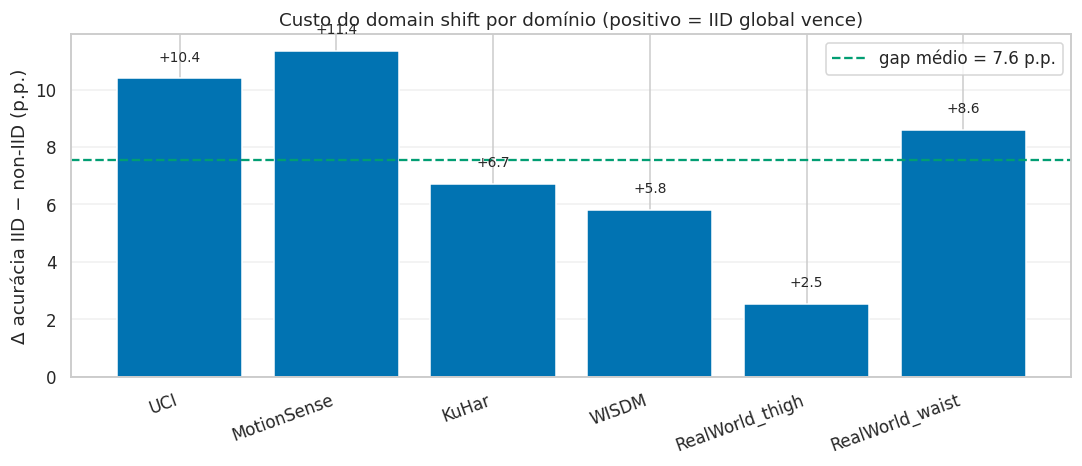

Acurácia global  — non-IID: 66.4%  |  IID global: 74.0%
Custo médio do domain shift: 7.6 pontos percentuais


In [14]:
# Gap por domínio e global (cenário 2 - cenário 1), na rodada final.
g1 = FINAL[FINAL["scenario"] == 1].groupby("target")["test_acc"].mean().reindex(DATASETS)
g2 = FINAL[FINAL["scenario"] == 2].groupby("target")["test_acc"].mean().reindex(DATASETS)
gap = (g2 - g1) * 100

fig, ax = plt.subplots(figsize=(10, 4.4))
colors = [C_IID if v >= 0 else C_NONIID for v in gap.values]
ax.bar(DATASETS, gap.values, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.axhline(gap.mean(), color=C_CENTRAL, ls="--", lw=1.5, label=f"gap médio = {gap.mean():.1f} p.p.")
for i, v in enumerate(gap.values):
    ax.text(i, v + (0.6 if v >= 0 else -1.4), f"{v:+.1f}", ha="center", fontsize=9)
ax.set_ylabel("Δ acurácia IID − non-IID (p.p.)")
ax.set_title("Custo do domain shift por domínio (positivo = IID global vence)")
ax.set_xticklabels(DATASETS, rotation=20, ha="right"); ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

print(f"Acurácia global  — non-IID: {g1.mean()*100:.1f}%  |  IID global: {g2.mean()*100:.1f}%")
print(f"Custo médio do domain shift: {gap.mean():.1f} pontos percentuais")

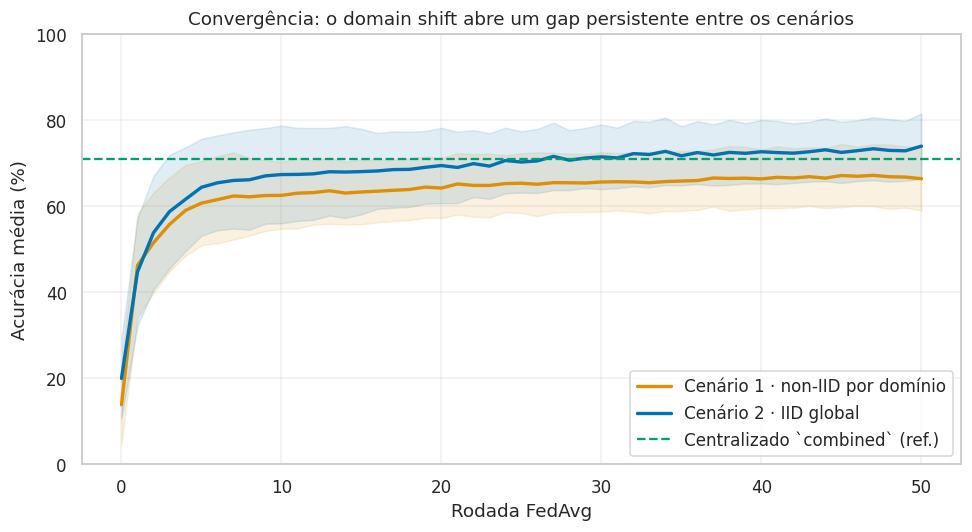

In [15]:
# Convergência comparada non-IID vs IID (média sobre encoders+seeds+domínios) + bandas.
fig, ax = plt.subplots(figsize=(9, 5))
for scen, color, lbl in [(1, C_NONIID, "non-IID por domínio"), (2, C_IID, "IID global")]:
    e = df[df["scenario"] == scen]
    # média por seed→round (sobre encoders e domínios), depois média/std sobre as curvas-seed
    per = e.groupby(["round"])["test_acc"].agg(["mean", "std"]).sort_index()
    ax.plot(per.index, per["mean"]*100, color=color, lw=2.2, label=f"Cenário {scen} · {lbl}")
    ax.fill_between(per.index, (per["mean"]-per["std"])*100, (per["mean"]+per["std"])*100,
                    color=color, alpha=0.12)
if central_combined is not None:
    ax.axhline(central_combined["test_acc"].mean()*100, color=C_CENTRAL, ls="--", lw=1.5,
               label="Centralizado `combined` (ref.)")
ax.set_xlabel("Rodada FedAvg"); ax.set_ylabel("Acurácia média (%)"); ax.set_ylim(0, 100)
ax.set_title("Convergência: o domain shift abre um gap persistente entre os cenários")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

### 5.2 Federado vs centralizado por encoder

In [16]:
# Gap federado (cenário 1 e 2) vs centralizado `combined`, por encoder.
if central_combined is not None:
    central_mean = central_combined["test_acc"].mean() * 100
    rows = []
    for enc in ENCODERS:
        r = {"encoder": ENCODER_LABEL[enc]}
        for scen in [1, 2]:
            acc = FINAL[(FINAL["encoder"] == enc) & (FINAL["scenario"] == scen)]["test_acc"].mean() * 100
            r[f"cenário {scen} ({scenario_short(scen)})"] = round(acc, 1)
        rows.append(r)
    comp = pd.DataFrame(rows).set_index("encoder")
    comp["centralizado `combined`"] = round(central_mean, 1)
    print("Acurácia média (%) — federado vs centralizado:")
    display(comp)
    print(f"\nReferência centralizada `combined` (média 6 domínios): {central_mean:.1f}%")
else:
    print("supervised_eval_transfer.csv ausente — referência centralizada indisponível.")

Acurácia média (%) — federado vs centralizado:


,cenário 1 (non-IID),cenário 2 (IID global),centralizado `combined`
encoder,,,
ResNet-SE-5,66.8,77.3,71.0
CNN-PFF,71.7,76.4,71.0
BiGRU,60.7,68.3,71.0



Referência centralizada `combined` (média 6 domínios): 71.0%


### 5.3 Matriz de transfer federada 6×6 (cenários 3..8)

Cada cenário 3..8 treina o modelo **federado IID** em **um** domínio (6 clientes
do mesmo dataset) e avalia nos 6. Empilhando os 6 cenários temos uma matriz
**fonte × alvo**: a **diagonal** é in-domain, o **off-diagonal** mede o quanto a
representação aprendida num domínio transfere para os outros — o domain shift
"por construção".

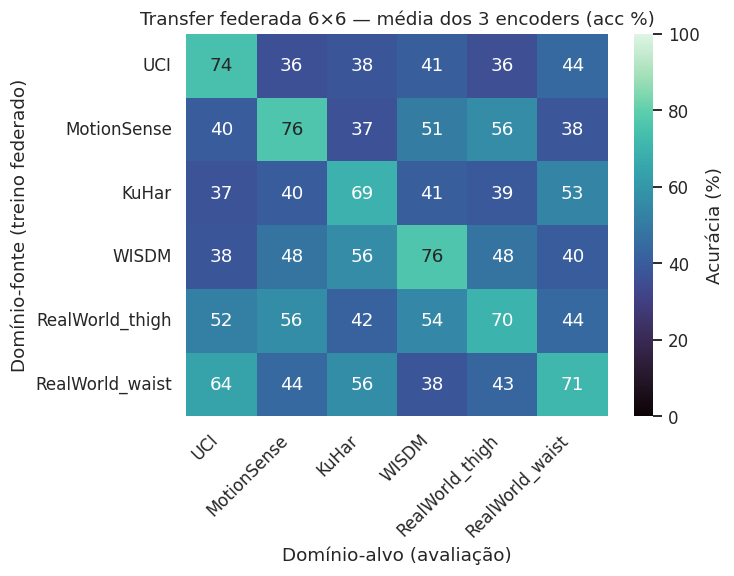

In-domain (diagonal):   72.8%  (min 68.8, max 76.2)
Cross-domain (off-diag): 44.9%
Queda média por domain shift: 27.8 pontos percentuais


In [17]:
def federated_transfer_matrix(encoder: str | None = None, metric: str = "test_acc"):
    """Matriz fonte(cenário 3..8) × alvo na rodada final."""
    f = FINAL[FINAL["scenario"].between(3, 8)]
    if encoder is not None:
        f = f[f["encoder"] == encoder]
    f = f.copy()
    f["source"] = f["scenario"].map(SCENARIO_TO_DATASET)
    mat = (f.groupby(["source", "target"])[metric].mean()
             .reindex(pd.MultiIndex.from_product([DATASETS, DATASETS], names=["source", "target"]))
             .unstack("target")[DATASETS].reindex(DATASETS))
    return mat * 100

def draw_transfer(mat, title):
    fig, ax = plt.subplots(figsize=(6.8, 5.4))
    if HAS_SNS:
        sns.heatmap(mat, annot=True, fmt=".0f", cmap=HEATMAP_CMAP, vmin=0, vmax=100,
                    ax=ax, cbar_kws={"label": "Acurácia (%)"})
    else:
        im = ax.imshow(mat.values, cmap=HEATMAP_CMAP, vmin=0, vmax=100)
        ax.set_xticks(range(len(DATASETS))); ax.set_xticklabels(DATASETS, rotation=45, ha="right")
        ax.set_yticks(range(len(DATASETS))); ax.set_yticklabels(DATASETS)
        for i in range(len(DATASETS)):
            for j in range(len(DATASETS)):
                ax.text(j, i, f"{mat.values[i,j]:.0f}", ha="center", va="center", color="w", fontsize=8)
        fig.colorbar(im, ax=ax, label="Acurácia (%)")
    ax.set_xlabel("Domínio-alvo (avaliação)"); ax.set_ylabel("Domínio-fonte (treino federado)")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    fig.tight_layout(); plt.show()

mat_all = federated_transfer_matrix(None, "test_acc")
draw_transfer(mat_all, "Transfer federada 6×6 — média dos 3 encoders (acc %)")

# Resumo diagonal vs off-diagonal
diag = np.diag(mat_all.values)
off = mat_all.values[~np.eye(len(DATASETS), dtype=bool)]
print(f"In-domain (diagonal):   {diag.mean():.1f}%  (min {diag.min():.1f}, max {diag.max():.1f})")
print(f"Cross-domain (off-diag): {off.mean():.1f}%")
print(f"Queda média por domain shift: {diag.mean() - off.mean():.1f} pontos percentuais")

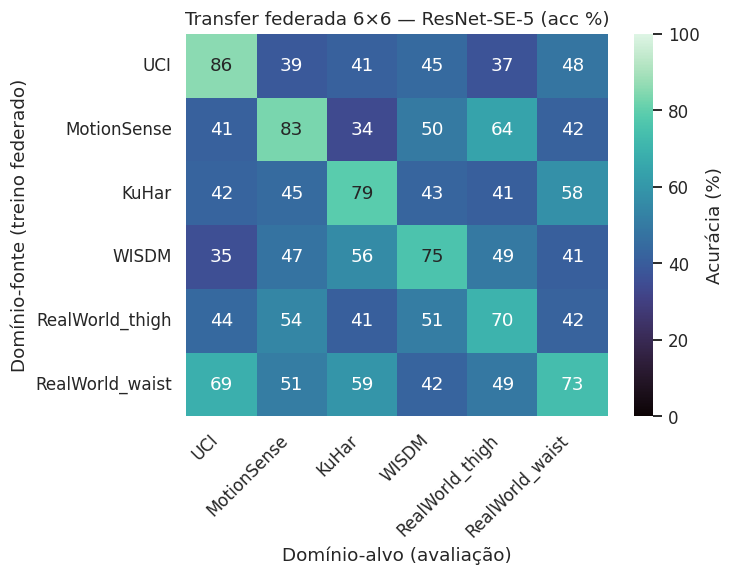

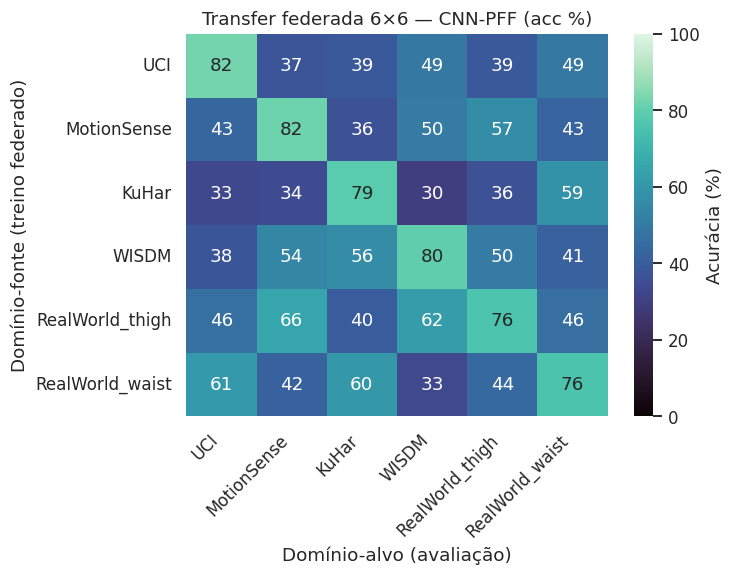

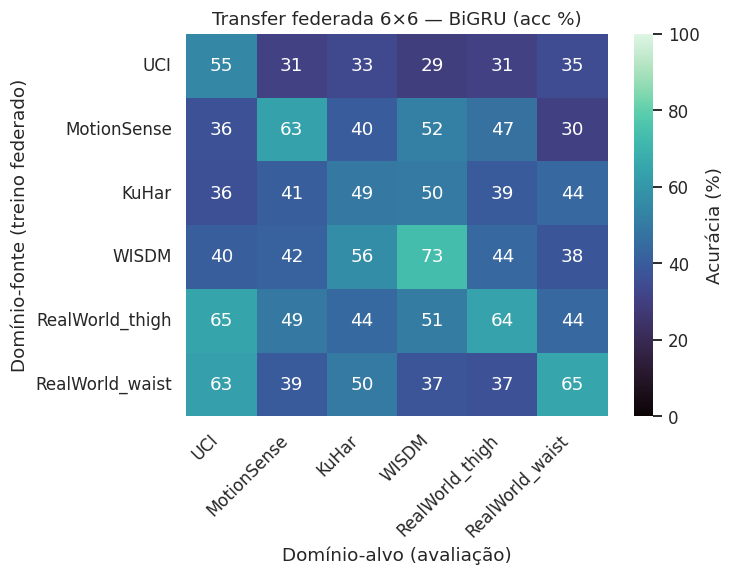

In [18]:
# Matriz de transfer federada por encoder (lado a lado).
fig_done = False
for enc in ENCODERS:
    draw_transfer(federated_transfer_matrix(enc, "test_acc"),
                  f"Transfer federada 6×6 — {ENCODER_LABEL[enc]} (acc %)")

## 6. Custo de comunicação

Terceira métrica oficial. `uplink_bytes`/`downlink_bytes` = bytes do `state_dict`
× nº de clientes, por rodada. A rodada 0 (avaliação dos pesos iniciais) não tem
custo. Analisamos o **custo por rodada**, o **acumulado** ao longo do treino e a
**eficiência** (acurácia alcançada por byte comunicado).

In [19]:
# Custo por rodada por encoder (constante ao longo das rodadas — depende do tamanho do modelo).
comm = df[df["round"] > 0].drop_duplicates(["encoder", "scenario", "seed", "round"])
per_round = comm.groupby("encoder")[["uplink_bytes", "downlink_bytes", "total_bytes"]].mean() / 1e6  # MB
per_round = per_round.reindex(ENCODERS)
per_round.index = [ENCODER_LABEL[e] for e in per_round.index]
print("Custo de comunicação por rodada (MB, média) — uplink+downlink agregados sobre 6 clientes:")
display(per_round.round(2))

# nº de parâmetros aproximado a partir do downlink (downlink = bytes_modelo × n_clientes; float32 = 4 bytes)
NUM_CLIENTS = 6
approx_params = (per_round["downlink_bytes"] * 1e6 / NUM_CLIENTS / 4).round(0)
print("\nParâmetros aprox. por encoder (a partir do downlink):")
display(approx_params.astype(int))

Custo de comunicação por rodada (MB, média) — uplink+downlink agregados sobre 6 clientes:


,uplink_bytes,downlink_bytes,total_bytes
ResNet-SE-5,3.29,3.29,6.58
CNN-PFF,3.50,3.50,7.00
BiGRU,4.10,4.10,8.21



Parâmetros aprox. por encoder (a partir do downlink):


ResNet-SE-5    137116
CNN-PFF        145830
BiGRU          170982
Name: downlink_bytes, dtype: int64

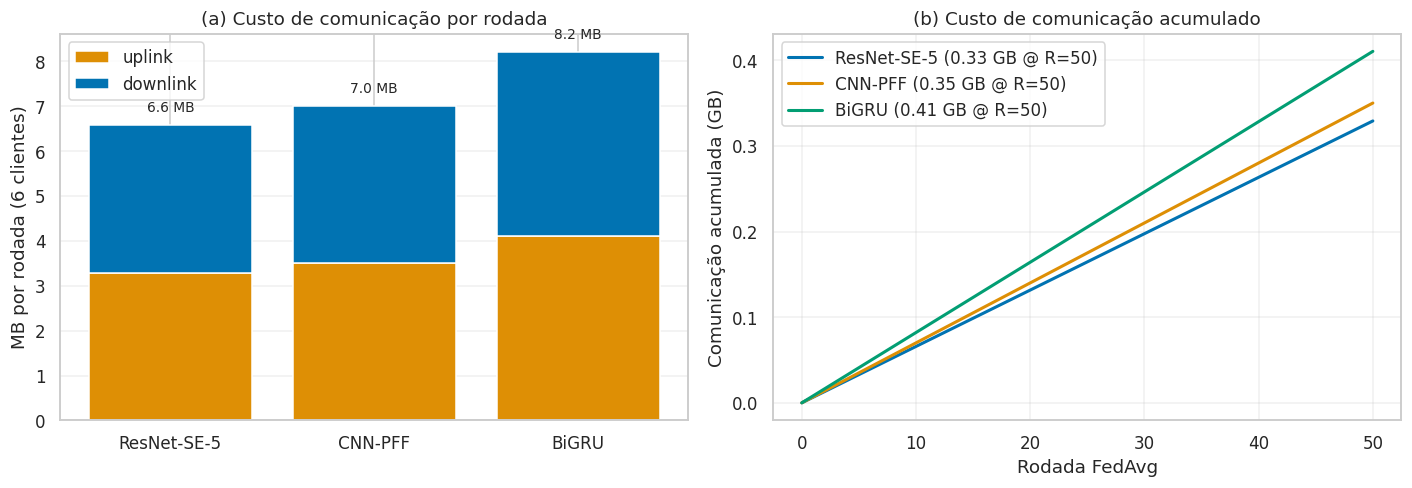

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) custo por rodada — barras empilhadas up/down por encoder
ax = axes[0]
labels = [ENCODER_LABEL[e] for e in ENCODERS]
up = [per_round.loc[ENCODER_LABEL[e], "uplink_bytes"] for e in ENCODERS]
dn = [per_round.loc[ENCODER_LABEL[e], "downlink_bytes"] for e in ENCODERS]
ax.bar(labels, up, color=C_NONIID, label="uplink")
ax.bar(labels, dn, bottom=up, color=C_IID, label="downlink")
for i, e in enumerate(ENCODERS):
    tot = per_round.loc[ENCODER_LABEL[e], "total_bytes"]
    ax.text(i, tot + 0.3, f"{tot:.1f} MB", ha="center", fontsize=9)
ax.set_ylabel("MB por rodada (6 clientes)"); ax.set_title("(a) Custo de comunicação por rodada")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# (b) custo acumulado ao longo das 50 rodadas
ax = axes[1]
for enc in ENCODERS:
    tot_round = per_round.loc[ENCODER_LABEL[enc], "total_bytes"]
    rounds = np.arange(0, LAST_ROUND + 1)
    ax.plot(rounds, rounds * tot_round / 1000, color=ENCODER_COLORS[enc], lw=2,
            label=f"{ENCODER_LABEL[enc]} ({LAST_ROUND*tot_round/1000:.2f} GB @ R={LAST_ROUND})")
ax.set_xlabel("Rodada FedAvg"); ax.set_ylabel("Comunicação acumulada (GB)")
ax.set_title("(b) Custo de comunicação acumulado"); ax.legend(loc="upper left"); ax.grid(alpha=0.3)

fig.tight_layout(); plt.show()

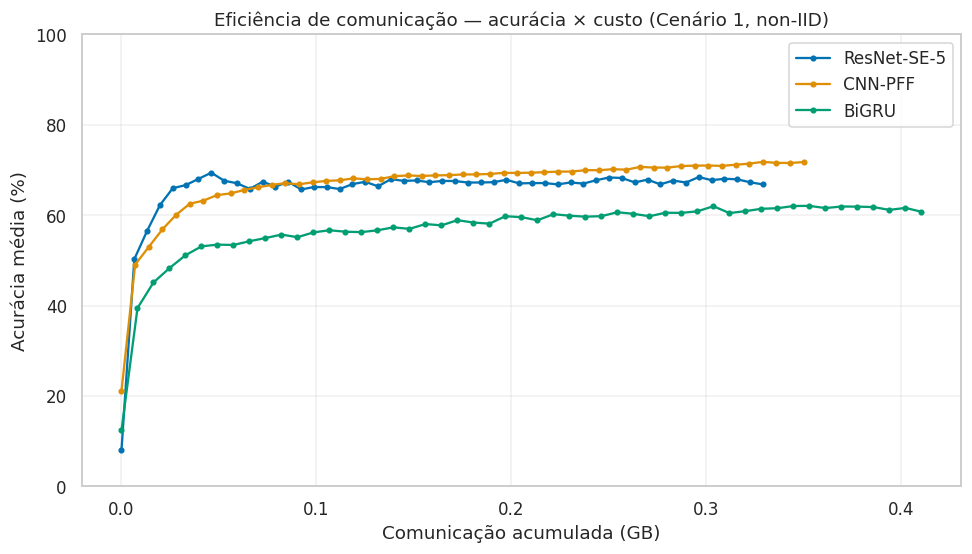

In [21]:
# Eficiência: acurácia média (cenário 1, non-IID — o caso oficial) vs comunicação acumulada.
fig, ax = plt.subplots(figsize=(9, 5.2))
for enc in ENCODERS:
    e = df[(df["encoder"] == enc) & (df["scenario"] == 1)]
    curve = e.groupby("round")["test_acc"].mean()
    tot_round = per_round.loc[ENCODER_LABEL[enc], "total_bytes"] / 1000  # GB/rodada
    cum_gb = curve.index.values * tot_round
    ax.plot(cum_gb, curve.values * 100, "-o", ms=3, color=ENCODER_COLORS[enc],
            label=ENCODER_LABEL[enc])
ax.set_xlabel("Comunicação acumulada (GB)"); ax.set_ylabel("Acurácia média (%)")
ax.set_title("Eficiência de comunicação — acurácia × custo (Cenário 1, non-IID)")
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 100)
fig.tight_layout(); plt.show()

## 7. Conclusões

- **Domain shift confirmado:** o Cenário 2 (IID global) supera o Cenário 1
  (non-IID por domínio) com o **mesmo volume total de dados** — o gap isola o
  custo da heterogeneidade entre clientes (Seção 5.1).
- **Federado IID ≈ centralizado:** o Cenário 2 aproxima-se (ou supera) o baseline
  `combined` centralizado, indicando que a federação em si custa pouco quando os
  dados são homogêneos (Seção 5.2).
- **Transfer federada (5.3):** forte na diagonal (in-domain) e fraca fora — a
  representação aprendida num domínio não transfere bem, motivando o SSL como
  próximo passo do plano.
- **Custo de comunicação (6):** cresce linearmente com as rodadas; os 3 encoders
  são leves (~127K params), então o gargalo é o número de rodadas, não o tamanho
  do modelo.

Próximos passos do plano: pré-treino **SSL** (LFR/TF-C) + *finetuning* federado,
comparando contra estes baselines federados supervisionados.